pip install tensorflow matplotlib numpy scikit-learn kagglehub

In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
import os

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [25]:
path = kagglehub.dataset_download(
    "vbookshelf/rice-leaf-diseases"
)

print("Downloaded Dataset Path:")
print(path)

Downloaded Dataset Path:
C:\Users\gaura\.cache\kagglehub\datasets\vbookshelf\rice-leaf-diseases\versions\1


In [30]:
import os

folders = os.listdir(path)

print("Folders Inside Dataset:")
print(folders)

dataset_path = os.path.join(
    path,
    folders[0]
)

print("\nUsing Dataset Path:")
print(dataset_path)

Folders Inside Dataset:
['rice_leaf_diseases']

Using Dataset Path:
C:\Users\gaura\.cache\kagglehub\datasets\vbookshelf\rice-leaf-diseases\versions\1\rice_leaf_diseases


In [31]:

IMG_SIZE = 64
BATCH_SIZE = 16


In [32]:
train_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="training",

    seed=123,

    image_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE
)


Found 120 files belonging to 3 classes.
Using 96 files for training.


In [33]:
# =========================
# STEP 6 : LOAD VALIDATION DATASET
# =========================

validation_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="validation",

    seed=123,

    image_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE
)

Found 120 files belonging to 3 classes.
Using 24 files for validation.


In [34]:
# =========================
# STEP 7 : CLASS NAMES
# =========================

class_names = train_dataset.class_names

print("\nClasses Found:")
print(class_names)

num_classes = len(class_names)


Classes Found:
['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [35]:
# =========================
# STEP 8 : NORMALIZATION
# =========================

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)


In [36]:

# =========================
# STEP 9 : PREFETCH
# =========================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [37]:
# =========================
# STEP 10 : BUILD CNN MODEL
# =========================

model = tf.keras.models.Sequential([

    tf.keras.Input(shape=(64,64,3)),


    # FIRST CNN LAYER
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),


    # SECOND CNN LAYER
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),


    # THIRD CNN LAYER
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),


    # FLATTEN LAYER
    tf.keras.layers.Flatten(),


    # DENSE LAYER
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),


    # DROPOUT
    tf.keras.layers.Dropout(0.5),


    # OUTPUT LAYER
    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )

])


In [38]:
# =========================
# STEP 11 : COMPILE MODEL
# =========================

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [39]:
# =========================
# STEP 12 : MODEL SUMMARY
# =========================

print("\nMODEL SUMMARY\n")

model.summary()




MODEL SUMMARY



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,587 (2.61 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# =========================
# STEP 13 : TRAIN MODEL
# =========================

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=50
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5104 - loss: 0.9522 - val_accuracy: 0.2500 - val_loss: 1.0718
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 1.0547 - val_accuracy: 0.2917 - val_loss: 1.0085
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5625 - loss: 0.9558 - val_accuracy: 0.7083 - val_loss: 0.9868
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6458 - loss: 0.8968 - val_accuracy: 0.3750 - val_loss: 1.0501
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5833 - loss: 0.8525 - val_accuracy: 0.4583 - val_loss: 0.9591
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6146 - loss: 0.8002 - val_accuracy: 0.5000 - val_loss: 0.8947
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6250 - loss: 0.7606 - val_accuracy: 0.4167 - val_loss: 1.0026
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6667 - loss: 0.6677 - val_accuracy: 0.7500 - val_loss: 0.6244


In [46]:

# =========================
# STEP 14 : EVALUATE MODEL
# =========================

loss, acc = model.evaluate(validation_dataset)

print("\nValidation Accuracy :", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7917 - loss: 0.7467

Validation Accuracy : 0.7916666865348816


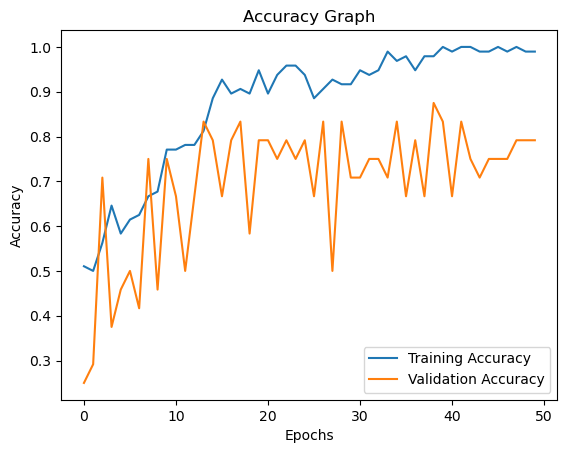

In [47]:
# =========================
# STEP 15 : ACCURACY GRAPH
# =========================

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("Accuracy Graph")

plt.legend()

plt.show()

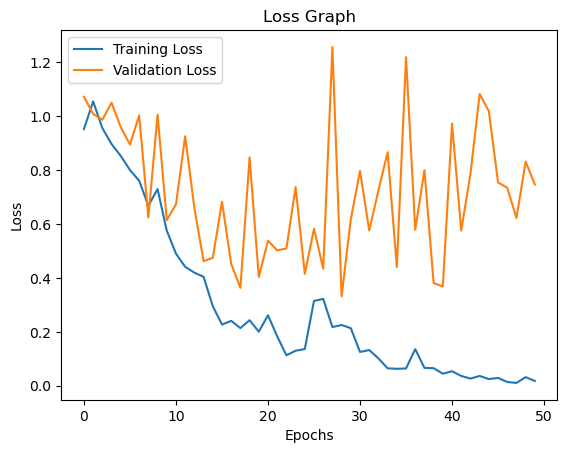

In [48]:
# =========================
# STEP 16 : LOSS GRAPH
# =========================

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Loss Graph")

plt.legend()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


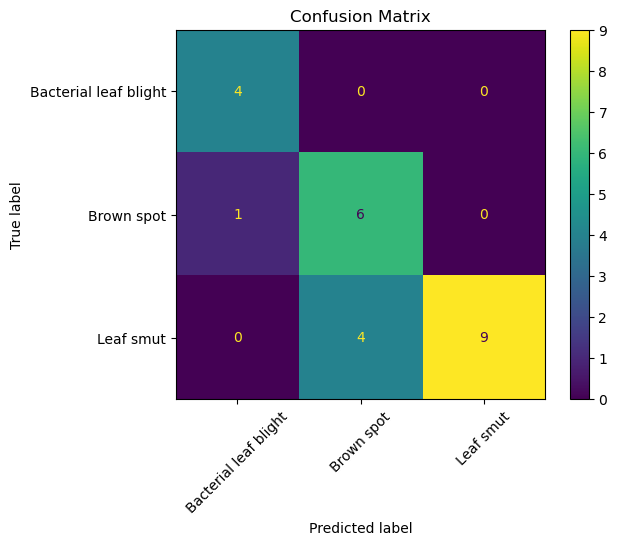

In [49]:
# =========================
# STEP 17 : CONFUSION MATRIX
# =========================

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names
)

disp.plot(
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.show()

In [50]:
# =========================
# STEP 18 : SAVE MODEL
# =========================

model.save("plant_disease_model.h5")

print("\nModel Saved Successfully")


Model Saved Successfully
